In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [4]:
data = sns.load_dataset('car_crashes')
df = data.copy()
df.head()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


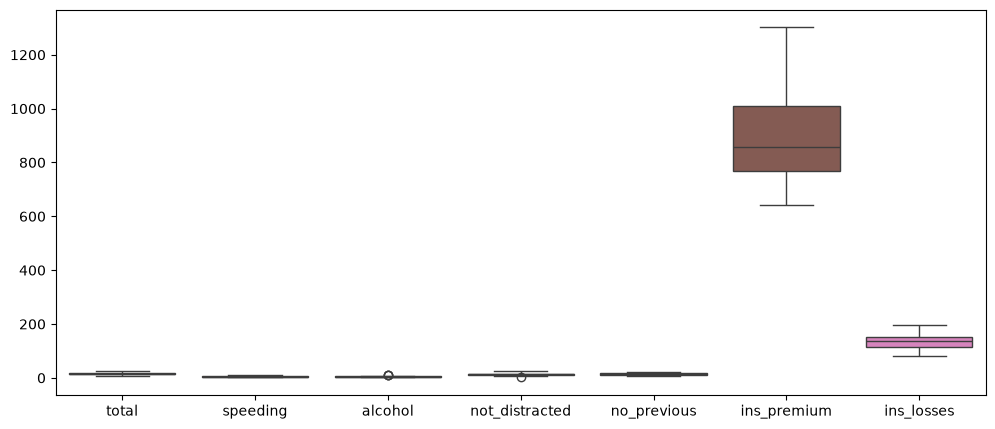

In [9]:
plt.figure(figsize=(12,5))
sns.boxplot(df)
plt.show()

In [10]:
df.shape

(51, 8)

In [13]:
df = df.drop(columns=['abbrev'])

In [14]:
df.head()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63


In [16]:
df_scaled = pd.DataFrame(scaler.fit_transform(df),columns= df.columns)
df_scaled.head()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses
0,0.737446,1.168148,0.439938,1.002301,0.277692,-0.580083,0.430514
1,0.565936,1.212695,-0.211311,0.608532,0.807258,0.943258,-0.022900
2,0.688443,0.756709,0.187615,0.459357,1.033141,0.070876,-0.981778
3,1.619498,-0.483614,0.547408,1.676052,1.951700,-0.337701,0.321125
4,-0.928653,-0.399524,-0.891763,-0.594276,-0.891968,-0.048418,1.266178


In [17]:
from sklearn.cluster import KMeans
kmean = KMeans(n_clusters= 4,random_state= 8)
label = kmean.fit_predict(df_scaled)
df_scaled['cluster'] = label
df_scaled.head()


,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,cluster
0,0.737446,1.168148,0.439938,1.002301,0.277692,-0.580083,0.430514,1
1,0.565936,1.212695,-0.211311,0.608532,0.807258,0.943258,-0.022900,1
2,0.688443,0.756709,0.187615,0.459357,1.033141,0.070876,-0.981778,1
3,1.619498,-0.483614,0.547408,1.676052,1.951700,-0.337701,0.321125,1
4,-0.928653,-0.399524,-0.891763,-0.594276,-0.891968,-0.048418,1.266178,2


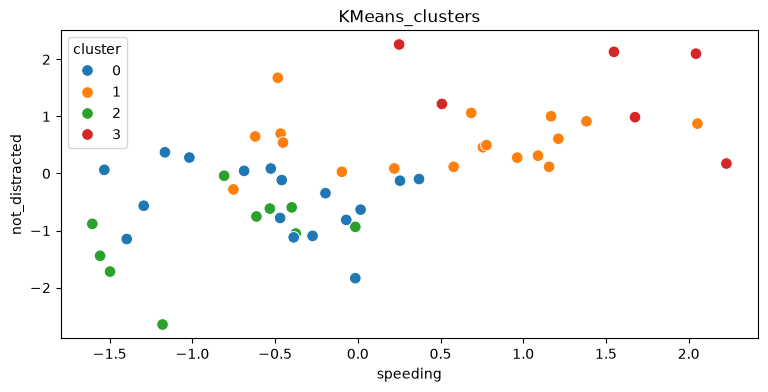

In [25]:
plt.figure(figsize=(9,4))
sns.scatterplot(x='speeding',y='not_distracted',data=df_scaled,hue='cluster',palette='tab10',s=70)
plt.title('KMeans_clusters')
plt.show()

In [28]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled.drop(columns=['cluster']))
df_scaled_pca = pd.DataFrame(df_pca,columns= ['pca_1','pca_2'])
df_scaled_pca.head()

,pca_1,pca_2
0,1.603671,0.133449
1,1.144212,0.858234
2,1.432172,-0.420506
3,2.491584,0.348968
4,-1.750638,0.633625


In [29]:
df_scaled_pca['pca_cluster']= kmean.fit_predict(df_scaled_pca)
df_scaled_pca.head()

,pca_1,pca_2,pca_cluster
0,1.603671,0.133449,2
1,1.144212,0.858234,2
2,1.432172,-0.420506,2
3,2.491584,0.348968,1
4,-1.750638,0.633625,3


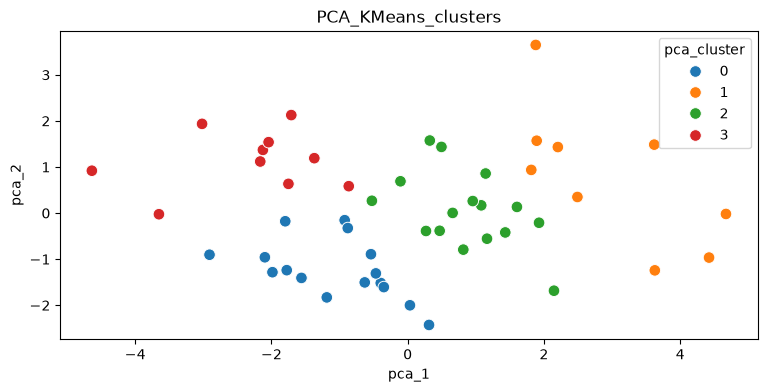

In [30]:
plt.figure(figsize=(9,4))
sns.scatterplot(x='pca_1',y='pca_2',data=df_scaled_pca,hue='pca_cluster',palette='tab10',s=70)
plt.title('PCA_KMeans_clusters')
plt.show()